## 라이브러리 호출 및 데이터 로드

In [2]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform
import ast
from collections import Counter
import json
from pprint import pprint

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

In [3]:
# 통계용 라이브러리 호출
from scipy import stats
import scikit_posthocs as sp

## User-level 데이터 재구성 사유 (요약)

* `explode` 과정에서 하나의 관측치가 여러 행으로 분할되어 **표본 수가 과대 증가**
* 동일 게임/유저 기반 데이터가 반복되며 **독립성 가정 위반**
* 이로 인해 **통계 검정 결과(p-value)가 왜곡될 가능성 존재**

따라서, User-level 데이터는 `explode` 없이 원본 구조를 유지하고,
분석은 **Game-level 기준으로 수행**하여 신뢰도를 확보함.

### 데이터 로드

In [18]:
# 데이터 로드
# 챔피언단위 -stats
df_champion = pd.read_csv('./preprocess_trial_csv/유저단위_게임데이터_상위랭커보존-stats_champion_1.csv')
# 챔피언단위 - explode
df_champion_explode = pd.read_csv('유저단위_게임데이터_상위랭커보존-explode_champion_1.csv')


#시너지단위
df_combination = pd.read_csv('./preprocess_trial_csv/유저단위_게임데이터_상위랭커보존-stats_combination_1.csv')
# 시너지단위 - explode
df_combination_explode = pd.read_csv('유저단위_게임데이터_상위랭커보존-explode_combination_1.csv')


#아이템단위
df_items = pd.read_csv('./preprocess_trial_csv/유저단위_게임데이터_상위랭커보존-stats_champion_items_1.csv')
#아이템단위 - explode
df_items_explode = pd.read_csv('유저단위_게임데이터_상위랭커보존-explode_items_1.csv')


In [5]:
df_champion.head()

,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,champions
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'origin': 'Rebel', 'class': ""['Demolitionist']""}, {'name': 'ashe', 'star': 1, 'cost': 3, 'origin': 'Celestial', 'class': ""['Sniper']""}, {'name': 'chogath', 'star': 1, 'cost': 4, 'origin': 'Void', 'class': ""['Brawler']""}, {'name': 'ekko', 'star': 1, 'cost': 5, 'origin': 'Cybernetic', 'class': ""['Infiltrator']""}]"
1,KR-USER-10,KR_4291614366,platinum,2,0,0,"{'Chrono': 4, 'DarkStar': 3, 'Brawler': 2, 'Sniper': 2}",True,False,"[{'name': 'malphite', 'star': 2, 'cost': 1, 'origin': 'Rebel', 'class': ""['Brawler']""}, {'name': 'caitlyn', 'star': 2, 'cost': 1, 'origin': 'Chrono', 'class': ""['Sniper']""}, {'name': 'blitzcrank', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': ""['Brawler']""}, {'name': 'shen', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': ""['Blademaster']""}, {'name': 'shaco', 'star': 2, 'cost': 3, 'origin': 'Dark Star', 'class': ""['Infiltrator']""}, {'name': 'lux', 'star': 1, 'cost': 3, 'origin': 'Dark Star', 'class': ""['Sorcerer']""}, {'name': 'wukong', 'star': 2, 'cost': 4, 'origin': 'Chrono', 'class': ""['Vanguard']""}, {'name': 'jhin', 'star': 2, 'cost': 4, 'origin': 'Dark Star', 'class': ""['Sniper']""}]"
2,KR-USER-100,KR_4392780319,platinum,2,0,0,"{'Blaster': 2, 'Demolitionist': 2, 'Mercenary': 1, 'Rebel': 6, 'Blademaster': 3, 'Valkyrie': 2}",True,False,"[{'name': 'ziggs', 'star': 2, 'cost': 1, 'origin': 'Rebel', 'class': ""['Demolitionist']""}, {'name': 'malphite', 'star': 3, 'cost': 1, 'origin': 'Rebel', 'class': ""['Brawler']""}, {'name': 'yasuo', 'star': 3, 'cost': 2, 'origin': 'Rebel', 'class': ""['Blademaster']""}, {'name': 'masteryi', 'star': 3, 'cost': 3, 'origin': 'Rebel', 'class': ""['Blademaster']""}, {'name': 'jinx', 'star': 2, 'cost': 4, 'origin': 'Rebel', 'class': ""['Blaster']""}, {'name': 'kayle', 'star': 1, 'cost': 4, 'origin': 'Valkyrie', 'class': ""['Blademaster']""}, {'name': 'missfortune', 'star': 1, 'cost': 5, 'origin': 'Valkyrie', 'class': ""['Mercenary', 'Blaster']""}, {'name': 'gangplank', 'star': 2, 'cost': 5, 'origin': 'Space Pirate', 'class': ""['Mercenary', 'Demolitionist']""}]"
3,KR-USER-1000,KR_4389301206,platinum,4,0,0,"{'Chrono': 2, 'ManaReaver': 2, 'Blademaster': 6, 'Celestial': 2}",True,False,"[{'name': 'fiora', 'star': 3, 'cost': 1, 'origin': 'Cybernetic', 'class': ""['Blademaster']""}, {'name': 'caitlyn', 'star': 3, 'cost': 1, 'origin': 'Chrono', 'class': ""['Sniper']""}, {'name': 'xayah', 'star': 2, 'cost': 1, 'origin': 'Celestial', 'class': ""['Blademaster']""}, {'name': 'shen', 'star': 3, 'cost': 2, 'origin': 'Chrono', 'class': ""['Blademaster']""}, {'name': 'kassadin', 'star': 2, 'cost': 3, 'origin': 'Celestial', 'class': ""['Mana-Reaver']""}, {'name': 'irelia', 'star': 2, 'cost': 4, 'origin': 'Cybernetic', 'class': ""['Mana-Reaver', 'Blademaster']""}, {'name': 'kayle', 'star': 2, 'cost': 4, 'origin': 'Valkyrie', 'class': ""['Blademaster']""}]"
4,KR-USER-10000,KR_4359165606,platinum,4,0,0,"{'Infiltrator': 4, 'MechPilot': 3, 'Valkyrie': 2}",True,False,"[{'name': 'khazix', 'star': 3, 'cost': 1, 'origin': 'Void', 'class': ""['Infiltrator']""}, {'name': 'kaisa', 'star': 3, 'cost': 2, 'origin': 'Valkyrie', 'class': ""['Infiltrator']""}, {'name': 'annie', 'star': 3, 'cost': 2, 'origin': 'Mech-Pilot', 'class': ""['Sorcerer']""}, {'name': 'shaco', 'star': 2, 'cost': 3, 'origin': 'Dark Star', 'class': ""['Infiltrator']""}, {'name': 'rumble', 'star': 3, 'cost': 3, 'origin': 'Mech-Pilot', 'class': ""['Demolitionist']""}, {'name': 'kayle', 'star': 1, 'cost': 4, 'origin': 'Valkyrie', 'class': ""['Blademaster']""}, {'name': 'fizz', 'star': 2, 'cost': 4, 'origin': 'Mech-Pilot', 'class': ""['Infiltrator']""}]"


In [19]:
df_champion_explode.head()

,gameid,user_id,user_tier,ranked,ranked_1,top4_flag,champion_name,items,star,flag_1,flag_2,name,cost,origin,class
0,KR_4291707834,KR-USER-1,platinum,5,False,False,ziggs,[7],1,0,0,ziggs,1,Rebel,Demolitionist
1,KR_4291707834,KR-USER-1,platinum,5,False,False,ashe,[9],1,0,0,ashe,3,Celestial,Sniper
2,KR_4291707834,KR-USER-1,platinum,5,False,False,chogath,[6],1,0,0,chogath,4,Void,Brawler
3,KR_4291707834,KR-USER-1,platinum,5,False,False,ekko,[1],1,0,0,ekko,5,Cybernetic,Infiltrator
4,KR_4291707834,KR-USER-2,platinum,3,False,True,ziggs,[24],3,0,0,ziggs,1,Rebel,Demolitionist


In [6]:
df_combination.head()

,gameid,user_tier,ranked,user_id,flag_1,flag_2,active_synergies,top4_flag,ranked_1,combination_rebuild
0,KR_4291707834,platinum,5,KR-USER-1,0,0,{},False,False,"{'Cybernetic': 1, 'Demolitionist': 1, 'Infiltrator': 1, 'Rebel': 1, 'Brawler': 1, 'Celestial': 1, 'Void': 1, 'Sniper': 1}"
1,KR_4291707834,platinum,3,KR-USER-2,0,0,"{'Cybernetic': 3, 'Vanguard': 2}",True,False,"{'Blaster': 1, 'Chrono': 1, 'Cybernetic': 4, 'Demolitionist': 1, 'Rebel': 1, 'Blademaster': 2, 'Brawler': 1, 'Sorcerer': 1, 'Void': 1, 'Valkyrie': 1, 'Vanguard': 2}"
2,KR_4291707834,platinum,7,KR-USER-3,0,0,{'Mercenary': 1},False,False,"{'Blaster': 1, 'Cybernetic': 1, 'DarkStar': 2, 'Infiltrator': 1, 'Mercenary': 1, 'Blademaster': 1, 'Mystic': 1, 'Valkyrie': 1}"
3,KR_4291707834,platinum,2,KR-USER-4,0,0,"{'Protector': 2, 'Celestial': 4, 'Vanguard': 2}",True,False,"{'DarkStar': 1, 'Protector': 2, 'Blademaster': 1, 'Celestial': 5, 'Mystic': 1, 'Sniper': 1, 'StarGuardian': 2, 'Vanguard': 2}"
4,KR_4291707834,platinum,1,KR-USER-5,0,0,"{'Chrono': 4, 'DarkStar': 3, 'Sorcerer': 2, 'Sniper': 2}",True,True,"{'Blaster': 1, 'Chrono': 5, 'DarkStar': 3, 'Protector': 1, 'Blademaster': 1, 'Brawler': 1, 'Sorcerer': 2, 'Sniper': 2}"


In [20]:
df_combination_explode.head()

,gameid,user_id,user_tier,ranked,top4_flag,ranked_1,flag_1,flag_2,active_synergies,synergy,synergy_val
0,KR_4291707834,KR-USER-1,platinum,5,False,False,0,0,{},Cybernetic,1
1,KR_4291707834,KR-USER-1,platinum,5,False,False,0,0,{},Demolitionist,1
2,KR_4291707834,KR-USER-1,platinum,5,False,False,0,0,{},Infiltrator,1
3,KR_4291707834,KR-USER-1,platinum,5,False,False,0,0,{},Rebel,1
4,KR_4291707834,KR-USER-1,platinum,5,False,False,0,0,{},Brawler,1


In [7]:
df_items.head()

,gameid,user_tier,ranked,champion,item_count,champion_count
0,KR_4291707834,platinum,5,"{'Ziggs': {'items': [7], 'star': 1}, 'Ashe': {'items': [9], 'star': 1}, 'ChoGath': {'items': [6], 'star': 1}, 'Ekko': {'items': [1], 'star': 1}}",4,4
1,KR_4291707834,platinum,3,"{'Ziggs': {'items': [24], 'star': 3}, 'Fiora': {'items': [37], 'star': 2}, 'Leona': {'items': [36, 24], 'star': 2}, 'Lucian': {'items': [], 'star': 2}, 'Vi': {'items': [5], 'star': 2}, 'Kayle': {'items': [], 'star': 2}, 'WuKong': {'items': [3, 67], 'star': 2}, 'VelKoz': {'items': [4], 'star': 2}}",8,8
2,KR_4291707834,platinum,7,"{'Fiora': {'items': [1], 'star': 1}, 'Shaco': {'items': [6], 'star': 1}, 'Karma': {'items': [4], 'star': 1}, 'MissFortune': {'items': [3], 'star': 1}}",4,4
3,KR_4291707834,platinum,2,"{'Poppy': {'items': [], 'star': 2}, 'Xayah': {'items': [19, 23, 19], 'star': 3}, 'Rakan': {'items': [], 'star': 2}, 'XinZhao': {'items': [16], 'star': 2}, 'Mordekaiser': {'items': [35, 67, 33], 'star': 3}, 'Ashe': {'items': [], 'star': 2}, 'Soraka': {'items': [68, 47], 'star': 2}}",9,7
4,KR_4291707834,platinum,1,"{'TwistedFate': {'items': [36, 27], 'star': 3}, 'Caitlyn': {'items': [49, 29], 'star': 2}, 'JarvanIV': {'items': [56], 'star': 2}, 'Blitzcrank': {'items': [15], 'star': 2}, 'Shen': {'items': [77, 6], 'star': 2}, 'Ezreal': {'items': [16], 'star': 2}, 'Lux': {'items': [], 'star': 2}, 'Jhin': {'items': [], 'star': 2}}",9,8


In [21]:
df_items_explode.head()

,gameid,user_id,user_tier,ranked,ranked_1,top4_flag,champion_name,items,star,flag_1,flag_2,name,cost,origin,class,item_count,item_id,item_name
0,KR_4291707834,KR-USER-1,platinum,5,False,False,ziggs,7.0,1,0,0,ziggs,1,Rebel,Demolitionist,1,7.0,Giant's Belt
1,KR_4291707834,KR-USER-1,platinum,5,False,False,ashe,9.0,1,0,0,ashe,3,Celestial,Sniper,1,9.0,Sparring Gloves
2,KR_4291707834,KR-USER-1,platinum,5,False,False,chogath,6.0,1,0,0,chogath,4,Void,Brawler,1,6.0,Negatron Cloak
3,KR_4291707834,KR-USER-1,platinum,5,False,False,ekko,1.0,1,0,0,ekko,5,Cybernetic,Infiltrator,1,1.0,B.F. Sword
4,KR_4291707834,KR-USER-2,platinum,3,False,True,ziggs,24.0,3,0,0,ziggs,1,Rebel,Demolitionist,1,24.0,Statikk Shiv


# 통계 

- top4_flag = 종속변수


# 전체 분포 확인(stats)

In [37]:
# =========================================================
# 0. 전체 분포 확인(stats)
# =========================================================

print("=" * 60)
print("0. 전체 top4_flag 분포(stats)")
print("=" * 60)

top4_summary = pd.DataFrame({
    'count': df_champion['top4_flag'].value_counts(),
    'ratio(%)': round(df_champion['top4_flag'].value_counts(normalize=True) * 100, 2)
})
print(top4_summary)

print("\n" + "=" * 60)
print("0-1. ranked(등수) 분포(stats)")
print("=" * 60)

rank_summary = pd.DataFrame({
    'count': df_champion['ranked'].value_counts().sort_index(),
    'ratio(%)': round(df_champion['ranked'].value_counts(normalize=True).sort_index() * 100, 2)
})
print(rank_summary)

print("\n" + "=" * 60)
print("0-2. user_tier 분포(stats)")
print("=" * 60)

tier_summary = pd.DataFrame({
    'count': df_champion['user_tier'].value_counts(),
    'ratio(%)': round(df_champion['user_tier'].value_counts(normalize=True) * 100, 2)
})
print(tier_summary)

0. 전체 top4_flag 분포(stats)
            count  ratio(%)
top4_flag                  
True       198145     50.01
False      198059     49.99

0-1. ranked(등수) 분포(stats)
        count  ratio(%)
ranked                 
1       49555     12.51
2       49500     12.49
3       49547     12.51
4       49543     12.50
5       49543     12.50
6       49539     12.50
7       49529     12.50
8       49448     12.48

0-2. user_tier 분포(stats)
              count  ratio(%)
user_tier                    
grand_master  79953     20.18
master        79930     20.17
challenger    79920     20.17
diamond       79456     20.05
platinum      76945     19.42


# cost vs top4 (explode파일 사용)

In [46]:
# 1-1. 챔피언 코스트별 top4 포함 비중 (explode 기준)"

print("\n" + "=" * 60)
print("1. 챔피언 코스트 분포(explode)")
print("=" * 60)

cost_summary = pd.DataFrame({
    'count': df_champion_explode['cost'].value_counts().sort_index(),
    'ratio(%)': round(df_champion_explode['cost'].value_counts(normalize=True).sort_index() * 100, 2)
})
print(cost_summary)

print("\n" + "=" * 60)
print("1-1. 챔피언 코스트별 top4 포함 비중 (explode 기준)")
print("=" * 60)

cost_top4_rate = (
    df_champion_explode.groupby('cost')['top4_flag']
    .agg(['size', 'mean'])
    .reset_index()
    .rename(columns={'size': 'count', 'mean': 'top4_rate'})
)

cost_top4_rate['top4_rate(%)'] = round(cost_top4_rate['top4_rate'] * 100, 2)
cost_top4_rate = cost_top4_rate.drop(columns='top4_rate')
print(cost_top4_rate)


1. 챔피언 코스트 분포(explode)
       count  ratio(%)
cost                  
1     583010     18.62
2     675898     21.59
3     840175     26.84
4     672612     21.48
5     359006     11.47

1-1. 챔피언 코스트별 top4 포함 비중 (explode 기준)
   cost   count  top4_rate(%)
0     1  583010         49.74
1     2  675898         48.86
2     3  840175         51.25
3     4  672612         53.00
4     5  359006         63.00


- 3코 챔피언 등장 비중이 가장 높음
- 5코 챔피언은 전체 등장 비중은 낮지만
- explode 기준으로는 top4 행 비중이 가장 높게 보임

# top4 vs 시너지 (explode파일 사용)

In [45]:
# 2. df_combination_explode 기준 기술통계
print("\n" + "=" * 60)
print("2. 시너지별 빈도(explode)")
print("=" * 60)

synergy_count = (
    df_combination_explode['synergy']
    .value_counts()
    .reset_index()
)
synergy_count.columns = ['synergy', 'count']
print(synergy_count)



2. 시너지별 빈도(explode)
          synergy   count
0          Chrono  262897
1      Cybernetic  210292
2        Vanguard  191019
3        DarkStar  189045
4       Celestial  180392
5        Valkyrie  178522
6         Blaster  176489
7         Brawler  167523
8     Blademaster  164365
9      ManaReaver  163442
10          Rebel  158625
11           Void  155532
12    SpacePirate  145983
13         Mystic  139478
14       Sorcerer  135965
15    Infiltrator  132318
16      Mercenary  127228
17         Sniper  102498
18   StarGuardian  101030
19      Protector   97612
20  Demolitionist   90318
21      MechPilot   67891
22       Starship   23200


- Chrono·Cybernetic·Vanguard 등은 전체 덱에서 자주 등장하는 핵심 시너지

In [44]:
# 2-1. 시너지별 top4 포함 비중(explode)
print("\n" + "=" * 60)
print("2-1. 시너지별 top4 포함 비중(explode)")
print("=" * 60)

synergy_summary = (
    df_combination_explode.groupby('synergy')['top4_flag']
    .agg(['size', 'mean'])
    .reset_index()
    .rename(columns={'size': 'count', 'mean': 'top4_rate'})
)

synergy_summary['top4_rate(%)'] = round(synergy_summary['top4_rate'] * 100, 2)
synergy_summary = synergy_summary.drop(columns='top4_rate').sort_values(
    by=['top4_rate(%)', 'count'],
    ascending=[False, False]
)
print(synergy_summary)


2-1. 시너지별 top4 포함 비중(explode)
          synergy   count  top4_rate(%)
19       Starship   23200         68.97
11      Mercenary  127228         60.62
20       Valkyrie  178522         54.88
12         Mystic  139478         53.40
22           Void  155532         52.84
5      Cybernetic  210292         52.49
3       Celestial  180392         51.97
1         Blaster  176489         51.97
4          Chrono  262897         51.77
9      ManaReaver  163442         51.69
6        DarkStar  189045         51.60
8     Infiltrator  132318         51.51
17    SpacePirate  145983         51.48
7   Demolitionist   90318         51.20
0     Blademaster  164365         51.15
10      MechPilot   67891         51.07
14          Rebel  158625         51.00
18   StarGuardian  101030         50.72
2         Brawler  167523         50.54
13      Protector   97612         50.04
15         Sniper  102498         49.80
16       Sorcerer  135965         49.20
21       Vanguard  191019         48.13


- 일부 시너지는 top4 유저 덱에 더 자주 포함되는 경향을 보였다

In [43]:
# 2-2. 시너지별 top4 포함 비중 상위 15개(explode)
print("\n" + "=" * 60)
print("2-2. 시너지별 top4 포함 비중 상위 15개(explode)")
print("=" * 60)
print(synergy_summary.head(15))


2-2. 시너지별 top4 포함 비중 상위 15개(explode)
          synergy   count  top4_rate(%)
19       Starship   23200         68.97
11      Mercenary  127228         60.62
20       Valkyrie  178522         54.88
12         Mystic  139478         53.40
22           Void  155532         52.84
5      Cybernetic  210292         52.49
3       Celestial  180392         51.97
1         Blaster  176489         51.97
4          Chrono  262897         51.77
9      ManaReaver  163442         51.69
6        DarkStar  189045         51.60
8     Infiltrator  132318         51.51
17    SpacePirate  145983         51.48
7   Demolitionist   90318         51.20
0     Blademaster  164365         51.15


- top4 포함 비중이 높은 시너지라도 등장 빈도가 낮은 경우 값이 상대적으로 불안정할 수 있으므로 해석 주의.

In [42]:
# 2-3. 시너지별 top4 포함 비중 하위 15개(explode)
print("\n" + "=" * 60)
print("2-3. 시너지별 top4 포함 비중 하위 15개(explode)")
print("=" * 60)
print(synergy_summary.tail(15))


2-3. 시너지별 top4 포함 비중 하위 15개(explode)
          synergy   count  top4_rate(%)
4          Chrono  262897         51.77
9      ManaReaver  163442         51.69
6        DarkStar  189045         51.60
8     Infiltrator  132318         51.51
17    SpacePirate  145983         51.48
7   Demolitionist   90318         51.20
0     Blademaster  164365         51.15
10      MechPilot   67891         51.07
14          Rebel  158625         51.00
18   StarGuardian  101030         50.72
2         Brawler  167523         50.54
13      Protector   97612         50.04
15         Sniper  102498         49.80
16       Sorcerer  135965         49.20
21       Vanguard  191019         48.13


**결론**
- 자주 쓰이는 시너지와 top4 덱에서 상대적으로 더 자주 보이는 시너지는 완전히 같지 않았으며, 일부 시너지는 성과가 더 높은 덱에서 더 두드러지는 경향을 보였다.

# top4 vs 아이템 (explode)

In [40]:
# 3. 아이템별 빈도(explode)
print("\n" + "=" * 60)
print("3. 아이템별 빈도(explode)")
print("=" * 60)

item_count = (
    df_items_explode['item_name']
    .value_counts()
    .reset_index()
)
item_count.columns = ['item_name', 'count']
print(item_count.head(30))



3. 아이템별 빈도(explode)
              item_name   count
0        Guardian Angel  219615
1        Morellonomicon  149190
2         Infinity Edge  147475
3           Quicksilver  140462
4      Seraph's Embrace  136808
5          Last Whisper  128426
6           Ionic Spark  121515
7              Red Buff  119540
8          Giant Slayer  101037
9                Zephyr   99554
10      Spear of Shojin   96060
11   Rabadon's Deathcap   92505
12  Guinsoo's Rageblade   88009
13     Chalice of Favor   81822
14         Frozen Heart   80727
15         Bramble Vest   79835
16     Rapid Firecannon   79317
17           Redemption   71240
18        Dragon's Claw   68556
19            Trap Claw   67808
20        Zz'Rot Portal   64903
21   Runaan's Hurricane   62521
22     Jeweled Gauntlet   62073
23       Thief's Gloves   61737
24      Titan's Resolve   60552
25         Luden's Echo   60239
26        Bloodthirster   56889
27      Hand Of Justice   56711
28         Statikk Shiv   53953
29     Hextech Gunb

- Guardian Angel, Morellonomicon, Infinity Edge, Quicksilver,Seraph's Embrace 아이템은 메타 전반에서 채용 빈도가 높은 아이템

In [38]:
# 3-1. 아이템별 top4 포함 비중(explode)
print("\n" + "=" * 60)
print("3-1. 아이템별 top4 포함 비중(explode)")
print("=" * 60)

item_summary = (
    df_items_explode.groupby('item_name')['top4_flag']
    .agg(['size', 'mean'])
    .reset_index()
    .rename(columns={'size': 'count', 'mean': 'top4_rate'})
)

item_summary['top4_rate(%)'] = round(item_summary['top4_rate'] * 100, 2)
item_summary = item_summary.drop(columns='top4_rate').sort_values(
    by=['top4_rate(%)', 'count'],
    ascending=[False, False]
)
print(item_summary)


3-1. 아이템별 top4 포함 비중(explode)
                    item_name   count  top4_rate(%)
39        Shroud of Stillness   37936         69.40
33                Rebel Medal   18138         65.87
24  Locket of the Iron Solari   47808         65.48
29     Protector's Chestguard   18103         65.34
51              Zeke's Herald   46548         64.60
45              Sword Breaker   34957         64.37
7           Dark Star's Heart   14246         63.62
36                 Redemption   71240         63.51
49                  Trap Claw   67808         63.50
1    Blade of the Ruined King   14628         61.91
17            Hand Of Justice   56711         61.37
43      Star Guardian's Charm   19109         61.29
4               Celestial Orb   23967         60.74
9      Demolitionist's Charge   35302         60.54
37         Runaan's Hurricane   62521         60.30
11            Force of Nature   26114         59.68
25               Luden's Echo   60239         59.66
19       Infiltrator's Talons   2

- 전체적으로 자주 쓰인 아이템과, top4 덱에서 상대적으로 더 자주 포함된 아이템은 서로 다를 수 있다

In [39]:
#3-2. 아이템별 top4 포함 비중 상위 15개(explode)
print("\n" + "=" * 60)
print("3-2. 아이템별 top4 포함 비중 상위 15개(explode)")
print("=" * 60)
print(item_summary.head(15))



3-2. 아이템별 top4 포함 비중 상위 15개(explode)
                    item_name  count  top4_rate(%)
39        Shroud of Stillness  37936         69.40
33                Rebel Medal  18138         65.87
24  Locket of the Iron Solari  47808         65.48
29     Protector's Chestguard  18103         65.34
51              Zeke's Herald  46548         64.60
45              Sword Breaker  34957         64.37
7           Dark Star's Heart  14246         63.62
36                 Redemption  71240         63.51
49                  Trap Claw  67808         63.50
1    Blade of the Ruined King  14628         61.91
17            Hand Of Justice  56711         61.37
43      Star Guardian's Charm  19109         61.29
4               Celestial Orb  23967         60.74
9      Demolitionist's Charge  35302         60.54
37         Runaan's Hurricane  62521         60.30


**짧은 결론**
- 일부 아이템은 상위권 덱 구성에서 더 자주 관찰되는 경향이 있다
- top4 포함 비중이 높은 아이템이라도 등장 빈도가 낮은 경우 비율이 과대하게 보일 수 있으므로 count를 함께 고려해야 한다.

---
# 통계 분석 정리

## 분석 목적
TFT 데이터에서 상위 시너지, 챔피언, 3성 여부가 성과 지표(Top4, ranked)와 어떤 관련이 있는지 확인한다.

---

## 분석 질문

1. 상위 5개 시너지의 포함 여부는 Top4와 관련이 있는가?
2. 상위 5개 시너지의 포함 여부는 ranked와 관련이 있는가?
3. 상위 5개 챔피언의 포함 여부는 Top4와 관련이 있는가?
4. 3성 챔피언 여부는 ranked와 관련이 있는가?
5. 티어별로 상위 5개 시너지의 Top4 비율이 다른가?

---

## 질문 1. 상위 5개 시너지의 포함 여부는 Top4와 관련이 있는가?

- **사용 데이터프레임**: `df_combination` -> `df_test_combination`(combination컬럼 str -> dict 변경)
- **검정 방법**: 카이제곱 검정
- **이유**: 시너지 포함 여부와 Top4 여부가 모두 범주형 변수이기 때문

### 가설
- **귀무가설(H0)**: 상위 5개 시너지의 포함 여부와 Top4 여부는 관련이 없다.
- **대립가설(H1)**: 상위 5개 시너지의 포함 여부와 Top4 여부는 관련이 있다.

### 해석 방향
- p-value가 유의수준보다 작으면 귀무가설을 기각한다.
- 즉, 시너지 포함 여부와 Top4 사이에 통계적으로 유의한 관련이 있다고 해석한다.

### 시각화
- 상위 5개 시너지 포함/미포함 Top4 비율 비교 막대그래프

### 한계
- 다른 조합 요소를 통제하지 못했다.
- 표본 수가 커서 작은 차이도 유의하게 나타날 수 있다.

In [ ]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

In [73]:
# 검정할 상위 빈도 top5 시너지
top5_synergies = ['Chrono', 'Cybernetic', 'Vanguard', 'DarkStar', 'Celestial']

In [155]:
# 문자열이면 dict로 바꿔주는 함수
def to_dict(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return {}
    return {}

In [154]:
df_test_combination = df_combination.copy()
df_test_combination['active_synergies'] = df_test_combination['active_synergies'].apply(to_dict)

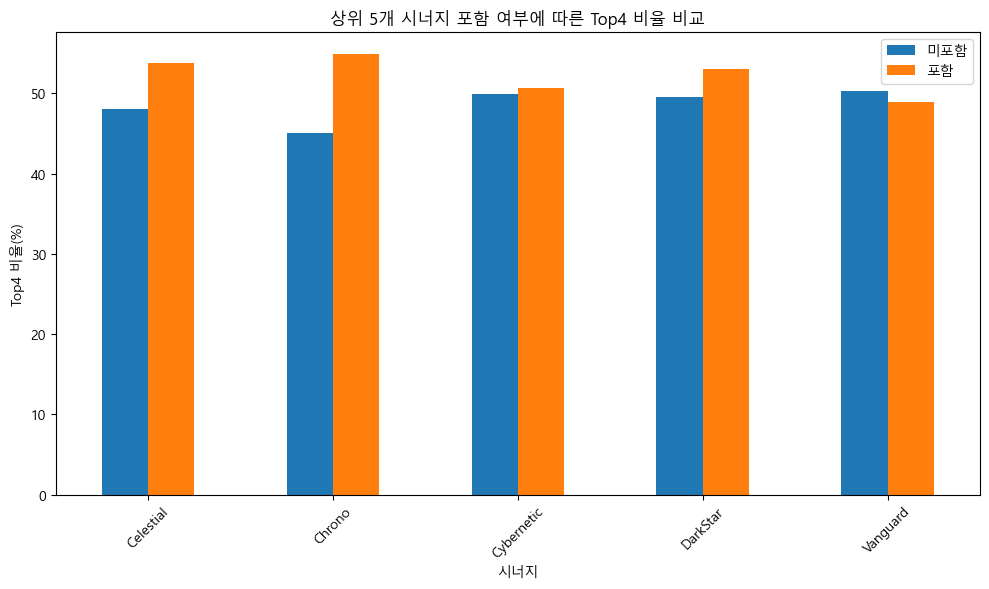

In [182]:
# 상위 5개 시너지 포함/미포함 top4 비율 비교 그래프
plot_data = []

for synergy in top5_synergies:
    temp = df_test_combination.copy()

    temp['has_synergy'] = temp['active_synergies'].apply(
        lambda x: synergy in x if isinstance(x, dict) else False
    )

    top4_with = temp.loc[temp['has_synergy'], 'top4_flag'].mean() * 100
    top4_without = temp.loc[~temp['has_synergy'], 'top4_flag'].mean() * 100

    plot_data.append({
        'synergy': synergy,
        '포함여부': '포함',
        'top4_rate': top4_with
    })
    plot_data.append({
        'synergy': synergy,
        '포함여부': '미포함',
        'top4_rate': top4_without
    })

plot_df = pd.DataFrame(plot_data)
plot_pivot = plot_df.pivot(index='synergy', columns='포함여부', values='top4_rate')

plot_pivot.plot(kind='bar', figsize=(10, 6))
plt.title('상위 5개 시너지 포함 여부에 따른 Top4 비율 비교')
plt.xlabel('시너지')
plt.ylabel('Top4 비율(%)')
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

In [195]:
df_test_combination = df_combination.copy()
df_test_combination['active_synergies'] = df_test_combination['active_synergies'].apply(to_dict)

results = []

for synergy in top5_synergies:

    # 이 시너지가 있는 행은 True, 없으면 False
    has_synergy = df_test_combination['active_synergies'].apply(lambda x: synergy in x)

    # 분할표 만들기
    ctab = pd.crosstab(has_synergy, df_test_combination['top4_flag'])
    ctab = ctab.reindex(index=[False, True], columns=[False, True], fill_value=0)

    # 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(ctab)

    # 포함 / 미포함 그룹 Top4 비율
    top4_with = df_test_combination.loc[has_synergy, 'top4_flag'].mean() * 100
    top4_without = df_test_combination.loc[~has_synergy, 'top4_flag'].mean() * 100

    # 결과 저장
    results.append({
        'synergy': synergy,
        'with_count': int(has_synergy.sum()),
        'without_count': int((~has_synergy).sum()),
        'top4_rate_with(%)': round(top4_with, 2),
        'top4_rate_without(%)': round(top4_without, 2),
        'chi2': round(chi2, 4),
        'p_value': p
    })

result_df = pd.DataFrame(results)

reject, pvals_fdr, _, _ = multipletests(result_df['p_value'], method='fdr_bh')
result_df['p_value_fdr'] = pvals_fdr
result_df['significant_fdr'] = reject

result_df.sort_values('p_value')

# 컬럼명 한국어로 변경
result_df_kor = result_df.rename(columns={
    'synergy': '시너지',
    'with_count': '포함 횟수',
    'without_count': '미포함 횟수',
    'top4_rate_with(%)': '포함 시 Top4 비율(%)',
    'top4_rate_without(%)': '미포함 시 Top4 비율(%)',
    'chi2': '카이제곱 통계량',
    'p_value': 'p값',
    'p_value_fdr': 'FDR 보정 p값',
    'significant_fdr': 'FDR 기준 유의 여부'
})

# True / False도 한글로 바꾸기
result_df_kor['FDR 기준 유의 여부'] = result_df_kor['FDR 기준 유의 여부'].map({
    True: '유의함',
    False: '유의하지 않음'
})

# 확인
result_df_kor.sort_values('p값')

,시너지,포함 횟수,미포함 횟수,포함 시 Top4 비율(%),미포함 시 Top4 비율(%),카이제곱 통계량,p값,FDR 보정 p값,FDR 기준 유의 여부
0,Chrono,200384,195855,54.86,45.05,3814.3378,0.000000e+00,0.000000e+00,유의함
1,Celestial,137136,259103,53.82,47.99,1220.1675,2.525617e-267,6.314042e-267,유의함
2,DarkStar,48084,348155,53.08,49.59,205.8317,1.115085e-46,1.858475e-46,유의함
3,Vanguard,81127,315112,48.90,50.30,50.3866,1.262518e-12,1.578147e-12,유의함
4,Cybernetic,41664,354575,50.64,49.94,7.3162,6.833756e-03,6.833756e-03,유의함


[결론]

- 상위 5개 시너지 모두 top4 여부와 유의한 연관이 있었다.
- Chrono, Celestial, DarkStar는 top4 비율 증가와 연관되었고, Vanguard는 top4 비율 감소와 연관되었다.
- Cybernetic은 유의했지만 비율 차이가 매우 작아 해석에 주의가 필요하다.

---
## 질문 2. 상위 5개 시너지의 포함 여부는 ranked와 관련이 있는가?

- **사용 데이터프레임**: `df_combination` -> `df_test_combination`(combination컬럼 str -> dict 변경)
- **검정 방법**: Mann-Whitney U 검정
- **이유**: ranked는 순위형 변수이며, 포함/미포함 두 집단의 분포 차이를 비교하기 때문

### 가설
- **귀무가설(H0)**: 상위 5개 시너지 포함 그룹과 미포함 그룹의 ranked 분포는 차이가 없다.
- **대립가설(H1)**: 상위 5개 시너지 포함 그룹과 미포함 그룹의 ranked 분포는 차이가 있다.

### 해석 방향
- p-value가 유의수준보다 작으면 귀무가설을 기각한다.
- 즉, 시너지 포함 여부에 따라 ranked 분포가 다르다고 해석한다.

### 시각화
- 상위 5개 시너지 포함/미포함 평균 등수 비교 막대그래프
- 상위 5개 시너지 포함/미포함 ranked 박스플롯

### 한계
- ranked의 분포 차이를 보는 것이므로, 평균 차이만으로 해석하면 부족할 수 있다.
- 인과관계가 아니라 관련성만 확인한 결과이다.

In [76]:
#상위 5개 시너지
top5_synergies = ['Chrono', 'Celestial', 'DarkStar', 'Vanguard', 'Cybernetic']

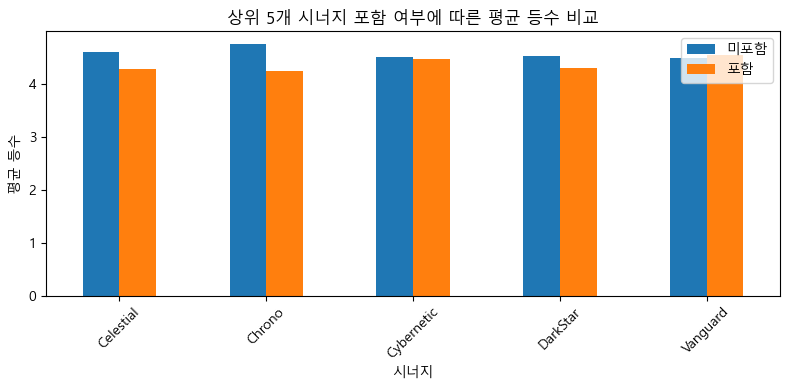

In [161]:
# 상위 5개 시너지 포함/미포함 평균 등수 비교 그래프
plot_data = []

for synergy in top5_synergies:
    temp = df_test_combination.copy()

    temp['has_synergy'] = temp['active_synergies'].apply(
        lambda x: synergy in x if isinstance(x, dict) else False
    )

    ranked_with_mean = temp.loc[temp['has_synergy'], 'ranked'].mean()
    ranked_without_mean = temp.loc[~temp['has_synergy'], 'ranked'].mean()

    plot_data.append({
        'synergy': synergy,
        '포함여부': '포함',
        'ranked_mean': ranked_with_mean
    })
    plot_data.append({
        'synergy': synergy,
        '포함여부': '미포함',
        'ranked_mean': ranked_without_mean
    })

plot_df = pd.DataFrame(plot_data)
plot_pivot = plot_df.pivot(index='synergy', columns='포함여부', values='ranked_mean')

plot_pivot.plot(kind='bar', figsize=(8, 4))
plt.title('상위 5개 시너지 포함 여부에 따른 평균 등수 비교')
plt.xlabel('시너지')
plt.ylabel('평균 등수')
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

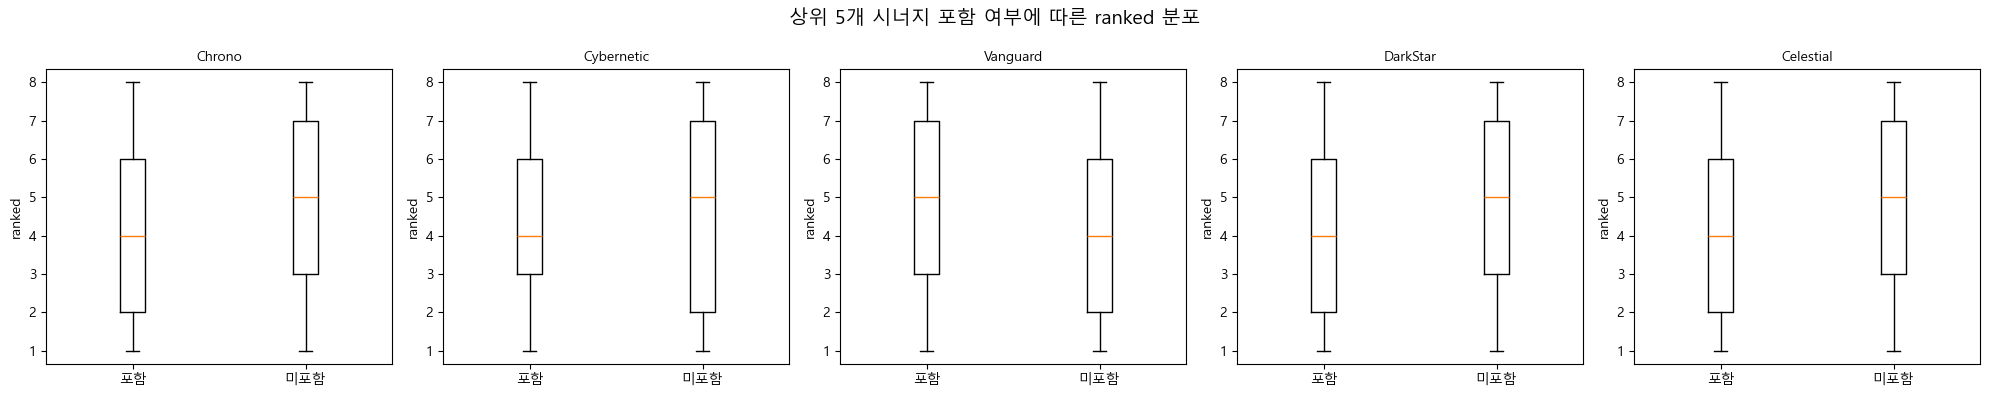

In [163]:
# 상위 5개 시너지별 ranked 분포 박스플롯
fig, axes = plt.subplots(1, len(top5_synergies), figsize=(20, 4))

for i, synergy in enumerate(top5_synergies):
    temp = df_test_combination.copy()

    temp['has_synergy'] = temp['active_synergies'].apply(
        lambda x: synergy in x if isinstance(x, dict) else False
    )

    ranked_with = temp.loc[temp['has_synergy'], 'ranked'].dropna()
    ranked_without = temp.loc[~temp['has_synergy'], 'ranked'].dropna()

    axes[i].boxplot([ranked_with, ranked_without], labels=['포함', '미포함'])
    axes[i].set_title(synergy, fontsize=10)
    axes[i].set_ylabel('ranked')

plt.suptitle('상위 5개 시너지 포함 여부에 따른 ranked 분포', fontsize=14)
plt.tight_layout()
plt.show()

In [186]:
# 검정 결과 저장용 리스트
results = []

# 상위 5개 시너지 하나씩 반복
for synergy in top5_synergies:

    # 1. 해당 시너지가 있으면 True, 없으면 False
    has_synergy = df_test_combination['active_synergies'].apply(
        lambda x: synergy in x if isinstance(x, dict) else False
    )

    # 2. 포함 / 미포함 그룹의 ranked 값 나누기
    ranked_with = df_test_combination.loc[has_synergy, 'ranked'].dropna()
    ranked_without = df_test_combination.loc[~has_synergy, 'ranked'].dropna()

    # 3. Mann-Whitney U 검정
    stat, p = mannwhitneyu(ranked_with, ranked_without, alternative='two-sided')

    # 4. 결과 저장
    results.append({
        'synergy': synergy,
        'with_count': int(has_synergy.sum()),
        'without_count': int((~has_synergy).sum()),
        'ranked_mean_with': round(ranked_with.mean(), 2),
        'ranked_mean_without': round(ranked_without.mean(), 2),
        'ranked_median_with': round(ranked_with.median(), 2),
        'ranked_median_without': round(ranked_without.median(), 2),
        'u_stat': stat,
        'p_value': p
    })

# 5. 결과표 만들기
result_ranked_df = pd.DataFrame(results)

# 6. FDR 보정
result_ranked_df['p_value_fdr'] = multipletests(
    result_ranked_df['p_value'],
    method='fdr_bh'
)[1]

# 7. 보정 후 유의 여부 표시
result_ranked_df['significant_fdr'] = result_ranked_df['p_value_fdr'] < 0.05

# 8. 보정된 p값 기준으로 정렬
result_ranked_df = result_ranked_df.sort_values('p_value_fdr')

# 9. 컬럼명 한글로 바꾸기
result_ranked_df = result_ranked_df.rename(columns={
    'synergy': '시너지',
    'with_count': '포함 게임 수',
    'without_count': '미포함 게임 수',
    'ranked_mean_with': '평균 등수 (포함)',
    'ranked_mean_without': '평균 등수 (미포함)',
    'ranked_median_with': '중앙값 등수 (포함)',
    'ranked_median_without': '중앙값 등수 (미포함)',
    'u_stat': 'U 통계량',
    'p_value': 'p값',
    'p_value_fdr': 'p값 (FDR 보정)',
    'significant_fdr': '유의 여부'
})

# 10. 결과 보기
result_ranked_df

,시너지,포함 게임 수,미포함 게임 수,평균 등수 (포함),평균 등수 (미포함),중앙값 등수 (포함),중앙값 등수 (미포함),U 통계량,p값,p값 (FDR 보정),유의 여부
0,Chrono,200384,195855,4.24,4.76,4.0,5.0,1.709865e+10,0.000000e+00,0.000000e+00,True
4,Celestial,137136,259103,4.29,4.61,4.0,5.0,1.632475e+10,0.000000e+00,0.000000e+00,True
3,DarkStar,48084,348155,4.31,4.53,4.0,5.0,7.922605e+09,4.146159e-82,6.910265e-82,True
2,Vanguard,81127,315112,4.55,4.49,5.0,4.0,1.299665e+10,9.718518e-14,1.214815e-13,True
1,Cybernetic,41664,354575,4.47,4.50,4.0,5.0,7.318822e+09,2.009979e-03,2.009979e-03,True


[결론]
- **상위 5개 시너지 모두 ranked 분포 차이가 유의하게 나타났다.**
- Chrono, Celestial, DarkStar, Cybernetic 시너지를 보유한 게임은 그렇지 않은 게임보다 평균 순위값이 낮아, 더 높은 등수(1등에 가까운 결과) 를 기록하는 경향이 있었다.
- 반면 Vanguard는 시너지 보유 시 평균 순위값이 오히려 소폭 높아져, 낮은 등수(꼴등에 가까운 방향)로 미세하게 불리한 것으로 나타났다.
- 다만 시너지 유무에 따른 평균 등수 차이 자체는 크지 않아, 시너지가 있다고 해서 극적으로 등수가 오르는 것은 아닐 수 있다.

---
## 질문 3. 상위 5개 챔피언의 포함 여부는 Top4와 관련이 있는가?

- **사용 데이터프레임**: `df_champion` -> `df_test_champion`(champion컬럼 str -> dict 변경)
- **검정 방법**: 카이제곱 검정
- **이유**: 챔피언 포함 여부와 Top4 여부가 모두 범주형 변수이기 때문

### 가설
- **귀무가설(H0)**: 상위 5개 챔피언의 포함 여부와 Top4 여부는 관련이 없다.
- **대립가설(H1)**: 상위 5개 챔피언의 포함 여부와 Top4 여부는 관련이 있다.

### 해석 방향
- p-value가 유의수준보다 작으면 귀무가설을 기각한다.
- 즉, 챔피언 포함 여부와 Top4 사이에 통계적으로 유의한 관련이 있다고 해석한다.

### 시각화
- 상위 5개 챔피언 Top4 비율 차이 그래프
- 상위 5개 챔피언 포함 횟수 그래프

### 한계
- 등장 빈도가 낮은 챔피언은 결과가 과대해석될 수 있다.
- 특정 챔피언 효과가 아니라 조합 전체 효과일 수도 있다.

In [115]:
df_test_champion = df_champion.copy()
df_test_champion['champions'] = df_test_champion['champions'].apply(to_dict)

In [ ]:
#상위 5개 챔피언 뽑기
champ_counter = Counter()

for x in df_test_champion['champions']:
    if isinstance(x, list):
        for champ in x:
            if isinstance(champ, dict) and 'name' in champ:
                champ_counter.update([champ['name']])

top5_champions = [champ for champ, cnt in champ_counter.most_common(5)]
top5_champions

['vi', 'blitzcrank', 'kassadin', 'ezreal', 'missfortune']

In [188]:
# 검정 결과 저장용 리스트
results = []

for champion in top5_champions:

    # 챔피언 포함 여부
    has_champion = df_test_champion['champions'].apply(
        lambda x: any(
            isinstance(ch, dict) and ch.get('name') == champion
            for ch in x
        ) if isinstance(x, list) else False
    )

    # 분할표
    ctab = pd.crosstab(has_champion, df_test_champion['top4_flag'])
    ctab = ctab.reindex(index=[False, True], columns=[False, True], fill_value=0)

    # 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(ctab)

    # Top4 비율
    top4_with = df_test_champion.loc[has_champion, 'top4_flag'].mean() * 100
    top4_without = df_test_champion.loc[~has_champion, 'top4_flag'].mean() * 100

    # 저장
    results.append({
        'champion': champion,
        'with_count': int(has_champion.sum()),
        'without_count': int((~has_champion).sum()),
        'top4_rate_with(%)': round(top4_with, 2),
        'top4_rate_without(%)': round(top4_without, 2),
        'chi2': round(chi2, 4),
        'p_value': p
    })

result_champion_df = pd.DataFrame(results)

# FDR 보정
result_champion_df['p_value_fdr'] = multipletests(
    result_champion_df['p_value'],
    method='fdr_bh'
)[1]

# 유의 여부
result_champion_df['significant_fdr'] = result_champion_df['p_value_fdr'] < 0.05

# 정렬
result_champion_df = result_champion_df.sort_values('p_value_fdr')

result_champion_df

,champion,with_count,without_count,top4_rate_with(%),top4_rate_without(%),chi2,p_value,p_value_fdr,significant_fdr
4,missfortune,105382,290822,62.09,45.63,8377.4106,0.000000e+00,0.000000e+00,True
0,vi,123554,272650,53.44,48.46,845.7984,5.956771e-186,1.489193e-185,True
3,ezreal,105788,290416,52.25,49.20,289.0183,8.136922e-65,1.356154e-64,True
2,kassadin,108656,287548,52.09,49.23,258.3244,3.978950e-58,4.973688e-58,True
1,blitzcrank,120040,276164,51.70,49.28,196.7088,1.091605e-44,1.091605e-44,True


In [189]:
# 한국어번역
result_champion_df_ko = result_champion_df.rename(columns={
    'champion': '챔피언',
    'with_count': '포함 개수',
    'without_count': '미포함 개수',
    'top4_rate_with(%)': '포함 top4 비율(%)',
    'top4_rate_without(%)': '미포함 top4 비율(%)',
    'chi2': '카이제곱 통계량',
    'p_value': 'p값',
    'p_value_fdr': 'FDR 보정 p값',
    'significant_fdr': 'FDR 유의 여부'
})
result_champion_df_ko

,챔피언,포함 개수,미포함 개수,포함 top4 비율(%),미포함 top4 비율(%),카이제곱 통계량,p값,FDR 보정 p값,FDR 유의 여부
4,missfortune,105382,290822,62.09,45.63,8377.4106,0.000000e+00,0.000000e+00,True
0,vi,123554,272650,53.44,48.46,845.7984,5.956771e-186,1.489193e-185,True
3,ezreal,105788,290416,52.25,49.20,289.0183,8.136922e-65,1.356154e-64,True
2,kassadin,108656,287548,52.09,49.23,258.3244,3.978950e-58,4.973688e-58,True
1,blitzcrank,120040,276164,51.70,49.28,196.7088,1.091605e-44,1.091605e-44,True


[결론]
- **상위 5개 챔피언 모두 포함 여부에 따라 Top4 비율 차이가 나타났으며, 통계적으로도 유의했다.**
- missfortune, vi, ezreal, kassadin, blitzcrank가 포함된 게임은 미포함 게임보다 Top4 비율이 더 높게 나타났다.
- 특히 missfortune은 포함 시 Top4 비율이 약 62%로, 미포함 시 약 45%보다 약 17%p 높아 상위 5개 챔피언 중 가장 큰 차이를 보였다.
- 다만 이 결과는 챔피언 포함 여부와 Top4의 관련성을 보여주는 것이며, 다른 조합 요소나 티어 차이를 통제한 인과 해석은 아니다.

---
## 질문 4. 3성 챔피언 여부는 ranked와 관련이 있는가?

- **사용 데이터프레임**: `df_champion` -> `df_test_champion`(combination컬럼 str -> dict 변경)
- **검정 방법**: Mann-Whitney U 검정
- **이유**: 3성 있음/없음 두 집단의 ranked 분포 차이를 비교하기 때문

### 가설
- **귀무가설(H0)**: 3성 챔피언이 있는 그룹과 없는 그룹의 ranked 분포는 차이가 없다.
- **대립가설(H1)**: 3성 챔피언이 있는 그룹과 없는 그룹의 ranked 분포는 차이가 있다.

### 해석 방향
- p-value가 유의수준보다 작으면 귀무가설을 기각한다.
- 즉, 3성 챔피언 여부에 따라 ranked 분포가 다르다고 해석한다.

### 시각화
- 3성 여부 ranked 박스플롯

### 한계
- 3성 여부 외 다른 요인의 영향이 함께 반영되었을 수 있다.
- 강한 조합에서 3성이 더 자주 등장했을 가능성을 통제하지 못했다.

In [118]:
# 3성 챔피언 보유 여부
df_test_champion['has_3star'] = df_test_champion['champions'].apply(
    lambda x: any(
        isinstance(ch, dict) and ch.get('star') == 3
        for ch in x
    ) if isinstance(x, list) else False
)

df_test_champion[['champions', 'has_3star']].head()

,champions,has_3star
0,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'origin': 'Rebel', 'class': '['Demolitionist']'}, {'name': 'ashe', 'star': 1, 'cost': 3, 'origin': 'Celestial', 'class': '['Sniper']'}, {'name': 'chogath', 'star': 1, 'cost': 4, 'origin': 'Void', 'class': '['Brawler']'}, {'name': 'ekko', 'star': 1, 'cost': 5, 'origin': 'Cybernetic', 'class': '['Infiltrator']'}]",False
1,"[{'name': 'malphite', 'star': 2, 'cost': 1, 'origin': 'Rebel', 'class': '['Brawler']'}, {'name': 'caitlyn', 'star': 2, 'cost': 1, 'origin': 'Chrono', 'class': '['Sniper']'}, {'name': 'blitzcrank', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': '['Brawler']'}, {'name': 'shen', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': '['Blademaster']'}, {'name': 'shaco', 'star': 2, 'cost': 3, 'origin': 'Dark Star', 'class': '['Infiltrator']'}, {'name': 'lux', 'star': 1, 'cost': 3, 'origin': 'Dark Star', 'class': '['Sorcerer']'}, {'name': 'wukong', 'star': 2, 'cost': 4, 'origin': 'Chrono', 'class': '['Vanguard']'}, {'name': 'jhin', 'star': 2, 'cost': 4, 'origin': 'Dark Star', 'class': '['Sniper']'}]",False
2,"[{'name': 'ziggs', 'star': 2, 'cost': 1, 'origin': 'Rebel', 'class': '['Demolitionist']'}, {'name': 'malphite', 'star': 3, 'cost': 1, 'origin': 'Rebel', 'class': '['Brawler']'}, {'name': 'yasuo', 'star': 3, 'cost': 2, 'origin': 'Rebel', 'class': '['Blademaster']'}, {'name': 'masteryi', 'star': 3, 'cost': 3, 'origin': 'Rebel', 'class': '['Blademaster']'}, {'name': 'jinx', 'star': 2, 'cost': 4, 'origin': 'Rebel', 'class': '['Blaster']'}, {'name': 'kayle', 'star': 1, 'cost': 4, 'origin': 'Valkyrie', 'class': '['Blademaster']'}, {'name': 'missfortune', 'star': 1, 'cost': 5, 'origin': 'Valkyrie', 'class': '['Mercenary', 'Blaster']'}, {'name': 'gangplank', 'star': 2, 'cost': 5, 'origin': 'Space Pirate', 'class': '['Mercenary', 'Demolitionist']'}]",True
3,"[{'name': 'fiora', 'star': 3, 'cost': 1, 'origin': 'Cybernetic', 'class': '['Blademaster']'}, {'name': 'caitlyn', 'star': 3, 'cost': 1, 'origin': 'Chrono', 'class': '['Sniper']'}, {'name': 'xayah', 'star': 2, 'cost': 1, 'origin': 'Celestial', 'class': '['Blademaster']'}, {'name': 'shen', 'star': 3, 'cost': 2, 'origin': 'Chrono', 'class': '['Blademaster']'}, {'name': 'kassadin', 'star': 2, 'cost': 3, 'origin': 'Celestial', 'class': '['Mana-Reaver']'}, {'name': 'irelia', 'star': 2, 'cost': 4, 'origin': 'Cybernetic', 'class': '['Mana-Reaver', 'Blademaster']'}, {'name': 'kayle', 'star': 2, 'cost': 4, 'origin': 'Valkyrie', 'class': '['Blademaster']'}]",True
4,"[{'name': 'khazix', 'star': 3, 'cost': 1, 'origin': 'Void', 'class': '['Infiltrator']'}, {'name': 'kaisa', 'star': 3, 'cost': 2, 'origin': 'Valkyrie', 'class': '['Infiltrator']'}, {'name': 'annie', 'star': 3, 'cost': 2, 'origin': 'Mech-Pilot', 'class': '['Sorcerer']'}, {'name': 'shaco', 'star': 2, 'cost': 3, 'origin': 'Dark Star', 'class': '['Infiltrator']'}, {'name': 'rumble', 'star': 3, 'cost': 3, 'origin': 'Mech-Pilot', 'class': '['Demolitionist']'}, {'name': 'kayle', 'star': 1, 'cost': 4, 'origin': 'Valkyrie', 'class': '['Blademaster']'}, {'name': 'fizz', 'star': 2, 'cost': 4, 'origin': 'Mech-Pilot', 'class': '['Infiltrator']'}]",True


In [119]:
summary_3star = df_test_champion.groupby('has_3star')['ranked'].agg(['count', 'mean', 'median'])
summary_3star

,count,mean,median
has_3star,,,
False,197542,5.08547,5.0
True,198662,3.91625,4.0


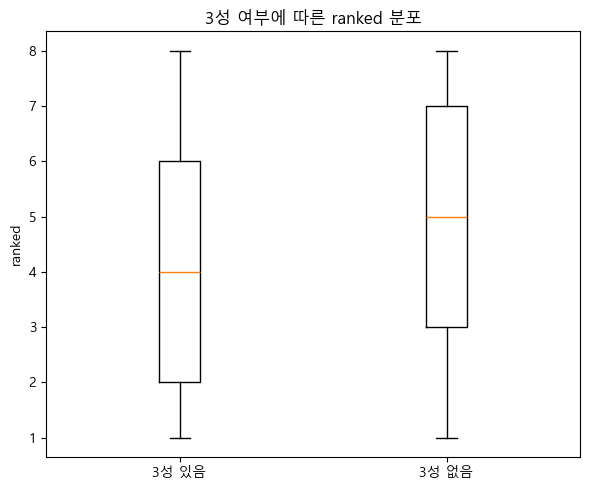

In [190]:
# 3성 여부에 따른 ranked 박스플롯
ranked_with_3star = df_test_champion.loc[df_test_champion['has_3star'], 'ranked'].dropna()
ranked_without_3star = df_test_champion.loc[~df_test_champion['has_3star'], 'ranked'].dropna()

plt.figure(figsize=(6, 5))
plt.boxplot([ranked_with_3star, ranked_without_3star], labels=['3성 있음', '3성 없음'])
plt.title('3성 여부에 따른 ranked 분포')
plt.ylabel('ranked')
plt.tight_layout()
plt.show()

In [ ]:
# 3성 여부에 따라 ranked 값 나누기
ranked_with_3star = df_test_champion.loc[df_test_champion['has_3star'], 'ranked'].dropna()
ranked_without_3star = df_test_champion.loc[~df_test_champion['has_3star'], 'ranked'].dropna()

# Mann-Whitney U 검정
u_stat, p_value = mannwhitneyu(
    ranked_with_3star,
    ranked_without_3star,
    alternative='two-sided'
)

# 결과표 만들기
result_3star_ranked = pd.DataFrame([{
    '비교': '3성 있음 vs 없음',
    '3성 있음 개수': len(ranked_with_3star),
    '3성 없음 개수': len(ranked_without_3star),
    '3성 있음 평균 등수': round(ranked_with_3star.mean(), 2),
    '3성 없음 평균 등수': round(ranked_without_3star.mean(), 2),
    '3성 있음 중앙 등수': ranked_with_3star.median(),
    '3성 없음 중앙 등수': ranked_without_3star.median(),
    'U 통계량': u_stat,
    'p값': p_value,
    '유의 여부': '유의함' if p_value < 0.05 else '유의하지 않음'
}])

result_3star_ranked

,비교,3성 있음 개수,3성 없음 개수,3성 있음 평균 등수,3성 없음 평균 등수,3성 있음 중앙 등수,3성 없음 중앙 등수,U 통계량,p값,유의 여부
0,3성 있음 vs 없음,198662,197542,3.92,5.09,4.0,5.0,1.388553e+10,0.0,유의함


- 박스와 중앙값이 더 아래에 있는 쪽이 더 좋은 등수!
- 3성 챔피언을 보유한 경우 더 좋은 등수 분포를 보이는 경향으로 해석

[결론]
- 3성 챔피언을 보유한 조합의 평균 등수는 3.92, 보유하지 않은 조합의 평균 등수는 5.09로, 3성 챔피언 보유 조합이 더 좋은 성과와 관련된 것으로 보인다.

---
## 질문 5. 티어별로 상위 5개 시너지의 Top4 비율이 다른가?

- **사용 데이터프레임**: `df_combination` -> `df_test_combination`(combination컬럼 str -> dict 변경)
- **검정 방법**: 카이제곱 검정
- **이유**: 티어와 Top4 여부가 모두 범주형 변수이기 때문

### 가설
- **귀무가설(H0)**: 티어에 따라 상위 5개 시너지의 Top4 비율 차이는 없다.
- **대립가설(H1)**: 티어에 따라 상위 5개 시너지의 Top4 비율 차이가 있다.

### 해석 방향
- p-value가 유의수준보다 작으면 귀무가설을 기각한다.
- 즉, 티어에 따라 특정 시너지의 Top4 비율이 다르다고 해석한다.

### 시각화
- 티어별 시너지 Top4 비율 히트맵
- 티어별 시너지 Top4 비율 막대그래프

### 추가 확인 사항
- 이 검정은 전체적으로 차이가 있는지만 보여준다.
- 어느 티어와 어느 티어가 다른지 보려면 사후비교가 추가로 필요하다.

### 한계
- 전체 차이만 확인했고, 세부 티어 간 차이는 사후분석이 필요하다.
- 티어 외 다른 변수의 영향은 분리하지 못했다.

In [192]:
# 상위 5개 시너지
top5_synergies = ['Chrono', 'Celestial', 'DarkStar', 'Vanguard', 'Cybernetic']

# 티어별 시너지 빈도 결과 저장용 리스트
rows = []

# 티어 하나씩 반복
for tier in sorted(df_test_combination['user_tier'].dropna().unique()):

    # 현재 티어 데이터만 따로 저장
    temp = df_test_combination[df_test_combination['user_tier'] == tier]

    # 현재 티어의 전체 게임 수
    total = len(temp)

    # 상위 5개 시너지 하나씩 반복
    for synergy in top5_synergies:

        # 현재 티어에서 해당 시너지가 포함된 게임 수
        count = temp['active_synergies'].apply(
            lambda x: synergy in x if isinstance(x, dict) else False
        ).sum()

        # 결과 저장
        rows.append({
            '티어': tier,
            '시너지': synergy,
            '개수': int(count),
            '비율(%)': round(count / total * 100, 2) if total > 0 else 0
        })

# 결과표 만들기
tier_synergy_count_df = pd.DataFrame(rows)

# 결과 보기
tier_synergy_count_df

,티어,시너지,개수,비율(%)
0,challenger,Chrono,38273,47.89
1,challenger,Celestial,28024,35.06
2,challenger,DarkStar,12593,15.76
3,challenger,Vanguard,13245,16.57
4,challenger,Cybernetic,10899,13.64
5,diamond,Chrono,44033,55.42
6,diamond,Celestial,28364,35.70
7,diamond,DarkStar,5784,7.28
8,diamond,Vanguard,18179,22.88
9,diamond,Cybernetic,6428,8.09


In [193]:
#가로
tier_synergy_rate_pivot = tier_synergy_count_df.pivot(
    index='시너지',
    columns='티어',
    values='비율(%)'
)

tier_synergy_rate_pivot

티어,challenger,diamond,grand_master,master,platinum
시너지,,,,,
Celestial,35.06,35.70,35.83,34.78,31.57
Chrono,47.89,55.42,58.24,50.39,40.58
Cybernetic,13.64,8.09,10.28,10.68,9.85
DarkStar,15.76,7.28,9.70,13.20,14.81
Vanguard,16.57,22.88,23.13,20.37,19.39


In [140]:
#티어별 주요 시너지 top4 비율 표
rows = []

for tier in sorted(df_test_combination['user_tier'].dropna().unique()):
    temp_tier = df_test_combination[df_test_combination['user_tier'] == tier]

    for synergy in top5_synergies:
        temp_synergy = temp_tier[
            temp_tier['active_synergies'].apply(
                lambda x: synergy in x if isinstance(x, dict) else False
            )
        ]

        rows.append({
            '티어': tier,
            '시너지': synergy,
            '표본수': len(temp_synergy),
            'top4 비율(%)': round(temp_synergy['top4_flag'].mean() * 100, 2) if len(temp_synergy) > 0 else None,
            '평균 등수': round(temp_synergy['ranked'].mean(), 2) if len(temp_synergy) > 0 else None,
            '중앙 등수': temp_synergy['ranked'].median() if len(temp_synergy) > 0 else None
        })

tier_synergy_perf_df = pd.DataFrame(rows)
tier_synergy_perf_df

,티어,시너지,표본수,top4 비율(%),평균 등수,중앙 등수
0,challenger,Chrono,38273,53.50,4.32,4.0
1,challenger,Celestial,28024,53.51,4.31,4.0
2,challenger,DarkStar,12593,53.29,4.29,4.0
3,challenger,Vanguard,13245,49.14,4.55,5.0
4,challenger,Cybernetic,10899,50.85,4.42,4.0
5,diamond,Chrono,44033,55.26,4.22,4.0
6,diamond,Celestial,28364,53.89,4.29,4.0
7,diamond,DarkStar,5784,52.44,4.36,4.0
8,diamond,Vanguard,18179,49.35,4.52,5.0
9,diamond,Cybernetic,6428,51.20,4.48,4.0


In [141]:
#티어별 시너지 top4 비율
print("=" * 15 + "티어별 시너지 top4 비율" + "=" * 15)
tier_synergy_top4_pivot = tier_synergy_perf_df.pivot(
    index='시너지',
    columns='티어',
    values='top4 비율(%)'
)

tier_synergy_top4_pivot

===============티어별 시너지 top4 비율===============


티어,challenger,diamond,grand_master,master,platinum
시너지,,,,,
Celestial,53.51,53.89,53.26,53.70,54.91
Chrono,53.50,55.26,54.60,55.03,56.13
Cybernetic,50.85,51.20,50.56,49.80,50.89
DarkStar,53.29,52.44,52.10,52.19,54.66
Vanguard,49.14,49.35,48.83,48.76,48.37


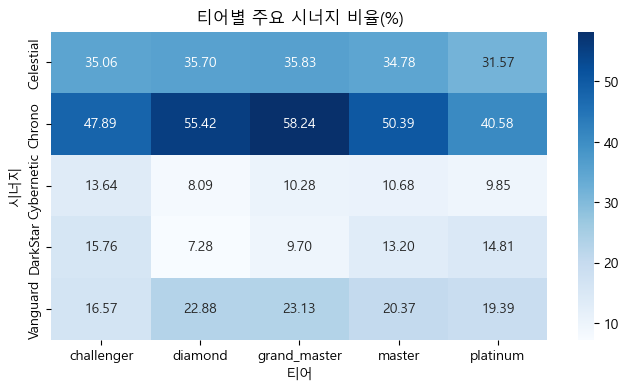

In [149]:
# 티어별 주요 시너지 비율(%) - 히트맵
# 티어별로 어떤 시너지가 상대적으로 많이 사용되었는지
plt.figure(figsize=(8, 4))
sns.heatmap(tier_synergy_rate_pivot, annot=True, fmt='.2f', cmap='Blues')
plt.title('티어별 주요 시너지 비율(%)')
plt.xlabel('티어')
plt.ylabel('시너지')
plt.show()

<Figure size 1000x500 with 0 Axes>

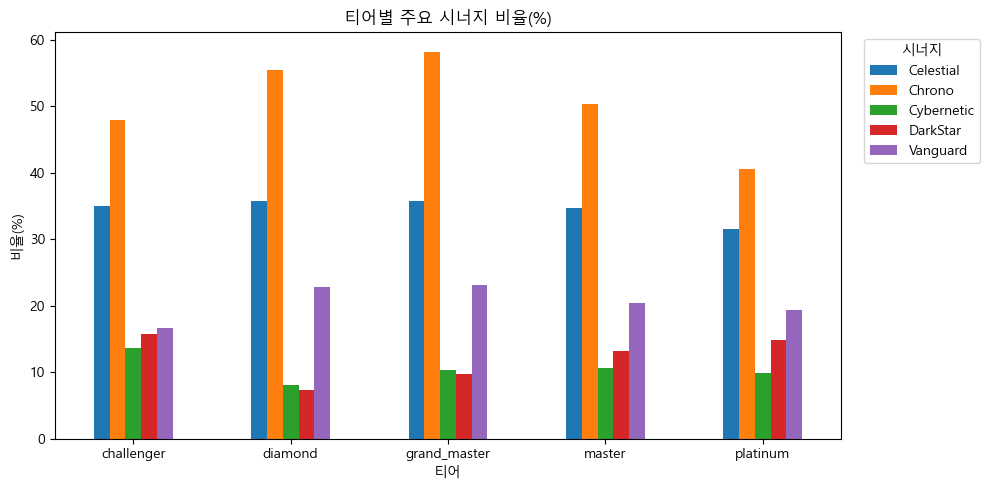

In [147]:
# 티어별 주요 시너지 비율(%) - 막대
plt.figure(figsize=(10, 5))
tier_synergy_rate_pivot.T.plot(kind='bar', figsize=(10, 5))
plt.title('티어별 주요 시너지 비율(%)')
plt.xlabel('티어')
plt.ylabel('비율(%)')
plt.xticks(rotation=0)
plt.legend(title='시너지', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

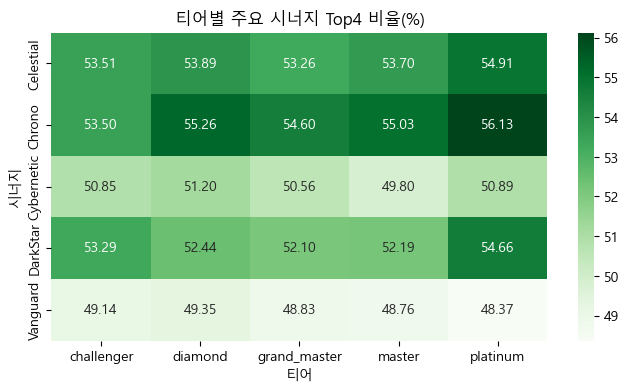

In [150]:
# 티어별 주요 시너지 Top4 비율(%) - 히트맵
# 티어별로 같은 시너지의 성과 차이
plt.figure(figsize=(8, 4))
sns.heatmap(tier_synergy_top4_pivot, annot=True, fmt='.2f', cmap='Greens')
plt.title('티어별 주요 시너지 Top4 비율(%)')
plt.xlabel('티어')
plt.ylabel('시너지')
plt.show()

### 같은 시너지를 쓴 조합안에서, 티어별로 top4 비율 차이가 있는가?
- 카이제곱 검정

In [194]:
# 검정 결과 저장용 리스트
results = []

# 상위 5개 시너지 하나씩 반복
for synergy in top5_synergies:

    # 1. 해당 시너지가 포함된 게임만 선택
    temp = df_test_combination[
        df_test_combination['active_synergies'].apply(
            lambda x: synergy in x if isinstance(x, dict) else False
        )
    ].copy()

    # 2. 티어와 Top4 여부로 분할표 만들기
    ctab = pd.crosstab(temp['user_tier'], temp['top4_flag'])

    # 3. False / True 열이 모두 있도록 맞춰주기
    ctab = ctab.reindex(columns=[False, True], fill_value=0)

    # 4. 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(ctab)

    # 5. 결과 저장
    results.append({
        '시너지': synergy,
        '표본수': len(temp),
        '카이제곱 통계량': round(chi2, 4),
        'p값': p
    })

# 6. 결과표 만들기
result_tier_top4_test = pd.DataFrame(results)

# 7. FDR 보정
result_tier_top4_test['p값 (FDR 보정)'] = multipletests(
    result_tier_top4_test['p값'],
    method='fdr_bh'
)[1]

# 8. 보정 후 유의 여부 표시
result_tier_top4_test['유의 여부'] = result_tier_top4_test['p값 (FDR 보정)'] < 0.05

# 9. 결과 보기
result_tier_top4_test

,시너지,표본수,카이제곱 통계량,p값,p값 (FDR 보정),유의 여부
0,Chrono,200384,53.2787,7.450660e-11,3.725330e-10,True
1,Celestial,137136,16.5505,2.362784e-03,3.937973e-03,True
2,DarkStar,48084,18.9478,8.047234e-04,2.011808e-03,True
3,Vanguard,81127,3.5888,4.645080e-01,4.645080e-01,False
4,Cybernetic,41664,3.6072,4.617628e-01,4.645080e-01,False


[결론]
- 상위 5개 시너지 중 Chrono, Celestial, DarkStar는 같은 시너지를 사용하더라도 티어에 따라 Top4 비율이 유의하게 달랐다.
- 반면 Vanguard, Cybernetic은 티어에 따른 Top4 비율 차이가 통계적으로 유의하지 않았다.
- 즉, 시너지의 성과는 시너지 자체뿐 아니라 이를 사용하는 티어 집단에 따라서도 달라질 수 있다.

[한계]
- 카이제곱 검정은 티어별 차이의 존재 여부만 알려주므로,
- 어느 티어 간 차이가 유의한지는 사후검정을 통해 추가 확인이 필요하다.

---
# 최종요약표

In [179]:
summary_table = pd.DataFrame({
    '질문': [
        '1.상위 5개 시너지의 포함 여부는 Top4와 관련이 있는가?',
        '2.상위 5개 시너지의 포함 여부는 ranked와 관련이 있는가?',
        '3.상위 5개 챔피언의 포함 여부는 Top4와 관련이 있는가?',
        '4.3성 챔피언 여부는 ranked와 관련이 있는가?',
        '5.티어별로 상위 5개 시너지의 Top4 비율이 다른가?'
    ],
    '사용 데이터프레임': [
        'df_combination',
        'df_combination',
        'df_champion',
        'df_champion',
        'df_combination'
    ],
    '검정 방법': [
        '카이제곱 검정',
        'Mann-Whitney U 검정',
        '카이제곱 검정',
        'Mann-Whitney U 검정',
        '카이제곱 검정'
    ],
    '핵심 결과': [
        '시너지 포함 여부에 따라 Top4 비율 차이가 나타남',
        '시너지 포함 여부에 따라 ranked 분포 차이가 나타남',
        '챔피언 포함 여부에 따라 Top4 비율 차이가 나타남',
        '3성 챔피언 여부에 따라 ranked 분포 차이가 나타남',
        '티어별 특정 시너지의 Top4 비율 차이가 나타남'
    ],
    '해석': [
        '시너지 포함 여부와 Top4 사이의 관련성이 확인됨',
        '시너지 포함 여부에 따라 등수 분포가 달라지는 패턴이 확인됨',
        '챔피언 포함 여부와 Top4 사이의 관련성이 확인됨',
        '3성 챔피언 여부에 따라 등수 분포가 달라지는 패턴이 확인됨',
        '티어에 따라 특정 시너지의 Top4 비율이 달라지는 경향이 확인됨'
    ],
    '한계': [
        '다른 조합 요소와 티어를 통제하지 못함',
        '큰 표본으로 작은 차이도 유의하게 나타날 수 있음',
        '등장 빈도가 낮은 챔피언은 해석에 주의가 필요함',
        '3성 여부 외 다른 요인의 영향이 함께 반영되었을 수 있음',
        '티어 외 다른 변수의 영향은 분리하지 못함'
    ]
})

summary_table.style.hide(axis='index')

질문,사용 데이터프레임,검정 방법,핵심 결과,해석,한계
1.상위 5개 시너지의 포함 여부는 Top4와 관련이 있는가?,df_combination,카이제곱 검정,시너지 포함 여부에 따라 Top4 비율 차이가 나타남,시너지 포함 여부와 Top4 사이의 관련성이 확인됨,다른 조합 요소와 티어를 통제하지 못함
2.상위 5개 시너지의 포함 여부는 ranked와 관련이 있는가?,df_combination,Mann-Whitney U 검정,시너지 포함 여부에 따라 ranked 분포 차이가 나타남,시너지 포함 여부에 따라 등수 분포가 달라지는 패턴이 확인됨,큰 표본으로 작은 차이도 유의하게 나타날 수 있음
3.상위 5개 챔피언의 포함 여부는 Top4와 관련이 있는가?,df_champion,카이제곱 검정,챔피언 포함 여부에 따라 Top4 비율 차이가 나타남,챔피언 포함 여부와 Top4 사이의 관련성이 확인됨,등장 빈도가 낮은 챔피언은 해석에 주의가 필요함
4.3성 챔피언 여부는 ranked와 관련이 있는가?,df_champion,Mann-Whitney U 검정,3성 챔피언 여부에 따라 ranked 분포 차이가 나타남,3성 챔피언 여부에 따라 등수 분포가 달라지는 패턴이 확인됨,3성 여부 외 다른 요인의 영향이 함께 반영되었을 수 있음
5.티어별로 상위 5개 시너지의 Top4 비율이 다른가?,df_combination,카이제곱 검정,티어별 특정 시너지의 Top4 비율 차이가 나타남,티어에 따라 특정 시너지의 Top4 비율이 달라지는 경향이 확인됨,티어 외 다른 변수의 영향은 분리하지 못함
